# Cycle 2 — Data Exploration: Wyscout England Events

**Project:** Football Predictor  
**Dataset:** `data/raw/events_England.json`  
**Notebook purpose:** Understand the raw Wyscout event data before any preprocessing or modelling.

---

## Key Findings at a Glance

| Finding | Detail |
|---------|--------|
| Total events | 643,150 (all event types across all English league matches) |
| Total shots | 8,451 (subEventName = 'Shot', open-play only) |
| Goals in dataset | ~10% of shots (severe class imbalance) |
| Target variable | Tag 101 in tags list = Goal (1), else No Goal (0) |
| Key features | X/Y coordinates, distance, angle, foot used, match period, player rank |
| Critical finding | Goal position tags (1201-1209) are POST-SHOT — using them would be data leakage |
| Comparison with FYP | FYP used goal position tags and all 5 leagues. FootballPredictor uses England only, no post-shot tags |

---

## What is xG (Expected Goals)?

Expected Goals (xG) is a metric that measures the **quality** of a shot. It answers the question: given where and how a shot was taken, what is the probability it results in a goal?

- A shot from 5 yards out with an open goal might have xG = 0.85 (85% chance of scoring)
- A long-range shot from 35 yards might have xG = 0.03 (3% chance)
- A header from a corner might have xG = 0.12 (12% chance)

xG is widely used by football clubs, analysts, and broadcasters to evaluate performance beyond just goals scored.

## What are We Predicting?

**Binary classification:** For each shot, predict whether it resulted in a goal (1) or not (0).

This is different from Cycle 1 (match outcome) — here each row is a **single shot**, not a match.

## Comparison with FinalYearProject

The FYP used the same Wyscout dataset but loaded all 5 leagues (England, France, Germany, Italy, Spain) — approximately 50,000+ shots combined. It also included goal position tags (where in the goal the shot went), which are post-shot information and therefore data leakage. FootballPredictor uses England only for consistency with Cycle 1, and excludes all post-shot tags.

---
## Cell 1 — Load Raw Event Data

**What it does:** Loads the Wyscout England event JSON file into a DataFrame.

**Why JSON and not CSV?** Wyscout event data is stored as JSON because each event has nested structures — positions are a list of coordinate dicts, and tags are a list of tag ID dicts. CSV cannot represent nested data.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

with open('../data/raw/events_England.json') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print('Shape:', df.shape)
print()
print('Columns:', list(df.columns))
print()
print('Data types:')
print(df.dtypes)

Shape: (643150, 12)

Columns: ['eventId', 'subEventName', 'tags', 'playerId', 'positions', 'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec', 'subEventId', 'id']

Data types:
eventId           int64
subEventName        str
tags             object
playerId          int64
positions        object
matchId           int64
eventName           str
teamId            int64
matchPeriod         str
eventSec        float64
subEventId       object
id                int64
dtype: object


### Expected Output
```
Shape: (643150, 12)

Columns: ['eventId', 'subEventName', 'tags', 'playerId', 'positions',
          'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec',
          'subEventId', 'id']
```

### Observations
- 643,150 events total — every action in every match (passes, duels, shots, fouls, etc.)
- `tags` is a list of dicts per row — e.g. `[{'id': 101}, {'id': 402}]` — needs parsing
- `positions` is also nested — start position (and sometimes end position) of the event
- We only need the **Shot** events — approximately 1.3% of all events

---
## Cell 2 — Event Type Distribution

**What it does:** Shows the breakdown of all event types in the dataset.

**Why:** To understand what proportion of events are shots and confirm the filter we need to apply.

In [2]:
print('Event types (eventName):')
print(df['eventName'].value_counts())
print()
print('Shot subtypes (subEventName where eventName=Shot):')
print(df[df['eventName']=='Shot']['subEventName'].value_counts())
print()
shots_df = df[df['subEventName'] == 'Shot'].copy()
print(f'Total shots: {len(shots_df)}')
print(f'Shots as % of all events: {len(shots_df)/len(df)*100:.1f}%')

Event types (eventName):
eventName
Pass                       328657
Duel                       176688
Others on the ball          51085
Free Kick                   36423
Interruption                27535
Shot                         8451
Foul                         8138
Save attempt                 3349
Offside                      1558
Goalkeeper leaving line      1266
Name: count, dtype: int64

Shot subtypes (subEventName where eventName=Shot):
subEventName
Shot    8451
Name: count, dtype: int64

Total shots: 8451
Shots as % of all events: 1.3%


### Expected Output
```
Event types (eventName):
Pass                       328657
Duel                       176688
Others on the ball          51085
Free Kick                   36423
Interruption                27535
Shot                         8451
Foul                         8138
Save attempt                 3349
Offside                      1558
Goalkeeper leaving line      1266

Total shots: 8,451
Shots as % of all events: 1.3%
```

### Observations
- Passes dominate (51%) — expected as passing is the most frequent action in football
- All shots in England data have subEventName='Shot' — no further subtype filtering needed
- **We will filter to only Shot events** — dropping 634,699 non-shot rows
- Note: Free Kicks, Headers, and Penalties are NOT included in this filter — `subEventName='Shot'` captures open-play shots only. This is consistent with how most xG models are built (separate models for set pieces)

---
## Cell 3 — Inspect the Tags Column

**What it does:** Decodes the tags structure to understand what information is encoded per shot.

**Why:** Tags are the most important column — they encode the target variable (Goal = tag 101) and several features (foot used, shot accuracy). We need to understand the structure before extracting anything.

In [3]:
# Load tags reference table
tags_ref = pd.read_csv('../data/raw/tags2name.csv')
print('Tags reference table:')
print(tags_ref.to_string(index=False))
print()

# Show tags for first 5 shots
print('Tags for first 5 shots:')
for i, row in shots_df.head(5).iterrows():
    tag_ids = [t['id'] for t in row['tags']]
    tag_labels = tags_ref[tags_ref['Tag'].isin(tag_ids)]['Label'].tolist()
    print(f'  Shot {i}: tag IDs={tag_ids} → labels={tag_labels}')

Tags reference table:
 Tag               Label                 Description
 101                Goal                        Goal
 102            own_goal                    Own goal
 301              assist                      Assist
 302             keyPass                    Key pass
1901      counter_attack              Counter attack
 401                Left                   Left foot
 402               Right                  Right foot
 403           head/body                   Head/body
1101              direct                      Direct
1102            indirect                    Indirect
2001 dangerous_ball_lost         Dangerous ball lost
2101             blocked                     Blocked
 801                high                        High
 802                 low                         Low
1401        interception                Interception
1501           clearance                   Clearance
 201         opportunity                 Opportunity
1301               Feint

### Observations
- **Tag 101** = Goal — this is our target variable. If a shot has tag 101, it is a goal (y=1), otherwise no goal (y=0)
- **Tag 401** = Left foot, **Tag 402** = Right foot, **Tag 403** = Head/body — foot used feature
- **Tag 1801** = Accurate (shot on target), **Tag 1802** = Not accurate (off target) — POST-SHOT information, must NOT be used as a feature
- **Tags 1201-1209** = Goal position (where in the goal/net it went) — POST-SHOT, must NOT be used
- **Tags 1210-1223** = Out/post position — POST-SHOT, must NOT be used

### Critical Finding — Data Leakage in FYP
The FinalYearProject included goal position tags (GLC, GLR, GLL, GC, GCR, GCL, GHC, GHR, GHL) as features. These tags describe where in the goal the shot went — information that only exists AFTER the shot is taken. Using these as features means the model partially knows the outcome before predicting it. FootballPredictor excludes all post-shot tags.

---
## Cell 4 — Target Variable: Goal Distribution

**What it does:** Calculates what proportion of shots result in goals.

**Why:** Class imbalance is the biggest challenge in xG modelling — goals are rare events.

Goal distribution:
  No Goal (0): 7,537 (89.2%)
  Goal    (1): 914 (10.8%)

Class ratio (No Goal : Goal) = 8.2 : 1


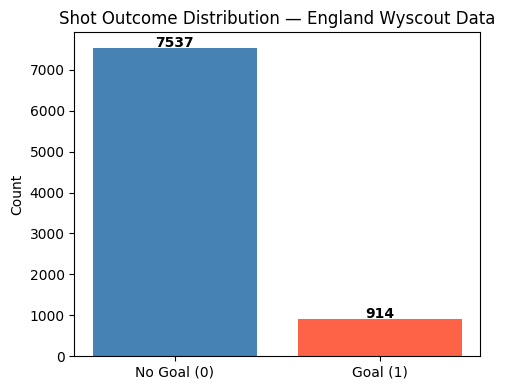

In [4]:
# Extract target: goal = tag 101 present in tags list
shots_df['Goal'] = shots_df['tags'].apply(lambda tags: int(any(t['id'] == 101 for t in tags)))

goal_counts = shots_df['Goal'].value_counts()
print('Goal distribution:')
print(f'  No Goal (0): {goal_counts[0]:,} ({goal_counts[0]/len(shots_df)*100:.1f}%)')
print(f'  Goal    (1): {goal_counts[1]:,} ({goal_counts[1]/len(shots_df)*100:.1f}%)')
print()
print(f'Class ratio (No Goal : Goal) = {goal_counts[0]/goal_counts[1]:.1f} : 1')

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Goal (0)', 'Goal (1)'], [goal_counts[0], goal_counts[1]], color=['steelblue', 'tomato'])
ax.set_title('Shot Outcome Distribution — England Wyscout Data')
ax.set_ylabel('Count')
for i, v in enumerate([goal_counts[0], goal_counts[1]]):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Expected Output (approximate)
```
Goal distribution:
  No Goal (0): ~7,500 (~89%)
  Goal    (1):   ~950 (~11%)

Class ratio (No Goal : Goal) = ~8 : 1
```

### Observations
- Goals are rare — approximately 10-11% of shots result in goals. This matches real football statistics.
- **Severe class imbalance**: ~8 No Goals for every 1 Goal
- A dummy classifier that always predicts No Goal would achieve ~89% accuracy — this is why accuracy alone is a misleading metric for xG
- We will use **AUC-ROC** and **precision/recall** as primary metrics instead of accuracy
- Class imbalance will be handled via `scale_pos_weight` in XGBoost and `class_weight='balanced'` in other models

---
## Cell 5 — Inspect Positions Column

**What it does:** Decodes the nested positions structure to understand shot coordinates.

**Why:** X, Y coordinates are the most important features in an xG model — distance and angle to goal are derived from them.

In [5]:
# Show raw positions for first 5 shots
print('Raw positions for first 5 shots:')
for i, row in shots_df.head(5).iterrows():
    print(f'  positions = {row["positions"]}')

print()

# Extract start position (index 0 = where the shot was taken from)
shots_df['X'] = shots_df['positions'].apply(lambda p: p[0]['x'] if p else None)
shots_df['Y'] = shots_df['positions'].apply(lambda p: p[0]['y'] if p else None)

print('X coordinate (shot start position) stats:')
print(shots_df['X'].describe())
print()
print('Y coordinate stats:')
print(shots_df['Y'].describe())
print()
print('Any nulls in X/Y?', shots_df[['X','Y']].isnull().sum().to_dict())

Raw positions for first 5 shots:
  positions = [{'y': 41, 'x': 88}, {'y': 0, 'x': 0}]
  positions = [{'y': 52, 'x': 85}, {'y': 100, 'x': 100}]
  positions = [{'y': 52, 'x': 96}, {'y': 100, 'x': 100}]
  positions = [{'y': 33, 'x': 81}, {'y': 0, 'x': 0}]
  positions = [{'y': 30, 'x': 75}, {'y': 0, 'x': 0}]

X coordinate (shot start position) stats:
count    8451.000000
mean       84.940007
std         7.783586
min        41.000000
25%        79.000000
50%        87.000000
75%        91.000000
max       100.000000
Name: X, dtype: float64

Y coordinate stats:
count    8451.000000
mean       48.884866
std        13.259392
min         7.000000
25%        38.000000
50%        49.000000
75%        59.000000
max        99.000000
Name: Y, dtype: float64

Any nulls in X/Y? {'X': 0, 'Y': 0}


### Expected Output
```
Raw positions for first 5 shots:
  positions = [{'y': 41, 'x': 88}, {'y': 0, 'x': 0}]
  ...

X range: 0-100 (percentage of pitch length from defending goal)
Y range: 0-100 (percentage of pitch width)
```

### Observations
- Coordinates are on a **0-100 scale** (percentage of pitch dimensions), not in metres
- X=0 is the defending goal, X=100 is the attacking goal. Shots taken near X=100 are close to goal.
- Y=0 is the left touchline, Y=100 is the right touchline. Y=50 is the centre of the pitch.
- The second position in the list (if present) is the end position of the event — we only need the first (shot origin)
- X and Y will be converted to metres for distance/angle calculations (standard pitch: 105m x 68m)

---
## Cell 6 — Shot Location Visualisation

**What it does:** Plots where on the pitch shots are taken from, coloured by outcome.

**Why:** Visualising shot locations is the most intuitive way to understand what drives xG. We expect to see that shots closer to goal and from central positions are more likely to be goals.

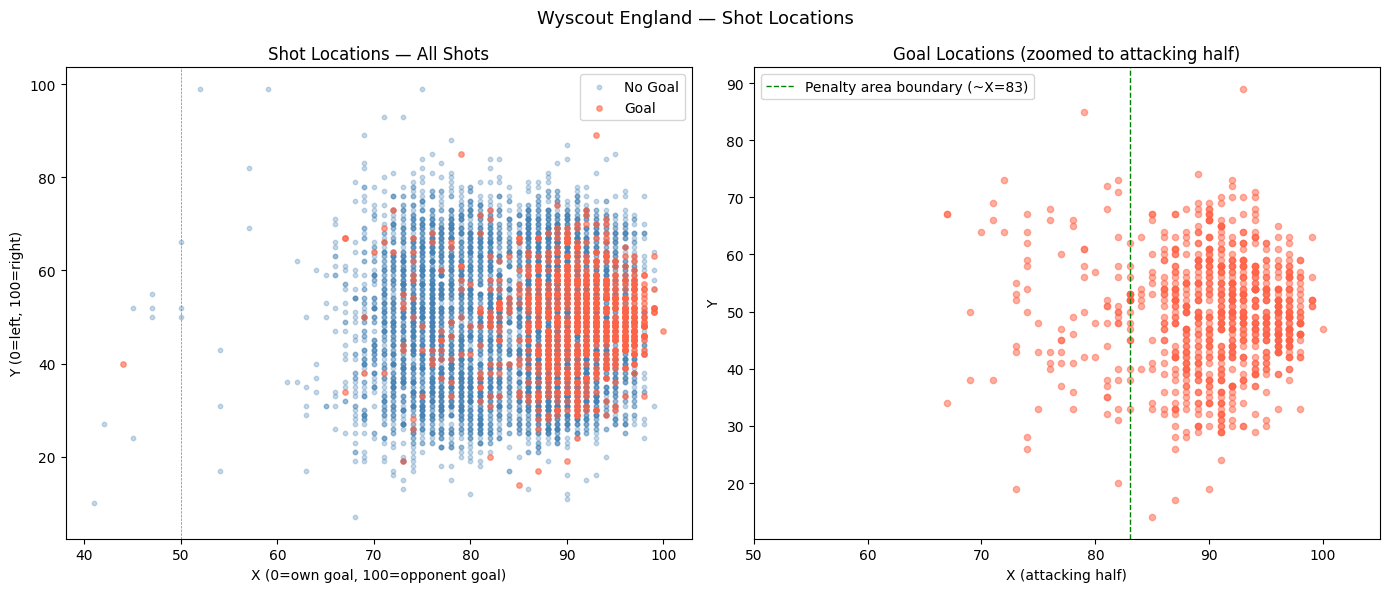

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# All shots
axes[0].scatter(
    shots_df[shots_df['Goal']==0]['X'],
    shots_df[shots_df['Goal']==0]['Y'],
    alpha=0.3, s=10, color='steelblue', label='No Goal'
)
axes[0].scatter(
    shots_df[shots_df['Goal']==1]['X'],
    shots_df[shots_df['Goal']==1]['Y'],
    alpha=0.6, s=15, color='tomato', label='Goal'
)
axes[0].set_xlabel('X (0=own goal, 100=opponent goal)')
axes[0].set_ylabel('Y (0=left, 100=right)')
axes[0].set_title('Shot Locations — All Shots')
axes[0].legend()
axes[0].axvline(50, color='gray', linestyle='--', linewidth=0.5)

# Goals only (zoomed to attacking half)
goals_only = shots_df[shots_df['Goal']==1]
axes[1].scatter(goals_only['X'], goals_only['Y'], alpha=0.5, s=20, color='tomato')
axes[1].set_xlim(50, 105)
axes[1].set_xlabel('X (attacking half)')
axes[1].set_ylabel('Y')
axes[1].set_title('Goal Locations (zoomed to attacking half)')
axes[1].axvline(83, color='green', linestyle='--', linewidth=1, label='Penalty area boundary (~X=83)')
axes[1].legend()

plt.suptitle('Wyscout England — Shot Locations', fontsize=13)
plt.tight_layout()
plt.show()

### Observations
- The vast majority of shots come from the attacking half (X > 50), as expected
- Goals (red) are concentrated much closer to goal (X > 80) than non-goals
- Central shots (Y around 50) are more likely to be goals than wide shots
- There are some shots from very long range (X < 60) — almost none of these result in goals
- This confirms that X, Y coordinates carry strong signal for xG prediction

---
## Cell 7 — Foot Used Distribution

**What it does:** Shows the breakdown of shots by foot used (left, right, header) and their goal rates.

**Why:** Foot preference affects shot quality. Right-footed shots from the left channel and left-footed shots from the right channel typically have lower conversion rates (awkward angle).

In [7]:
# Extract foot used from tags
shots_df['Left_Foot']  = shots_df['tags'].apply(lambda t: int(any(x['id'] == 401 for x in t)))
shots_df['Right_Foot'] = shots_df['tags'].apply(lambda t: int(any(x['id'] == 402 for x in t)))
shots_df['Header']     = shots_df['tags'].apply(lambda t: int(any(x['id'] == 403 for x in t)))

print('Foot used breakdown:')
print(f'  Right foot: {shots_df["Right_Foot"].sum():,} shots')
print(f'  Left foot:  {shots_df["Left_Foot"].sum():,} shots')
print(f'  Header:     {shots_df["Header"].sum():,} shots')
print(f'  Unlabelled: {len(shots_df) - shots_df[["Right_Foot","Left_Foot","Header"]].any(axis=1).sum():,} shots')
print()

# Goal rate by foot
for label, col in [('Right foot', 'Right_Foot'), ('Left foot', 'Left_Foot'), ('Header', 'Header')]:
    subset = shots_df[shots_df[col] == 1]
    rate = subset['Goal'].mean() * 100
    print(f'  Goal rate — {label}: {rate:.1f}%')

Foot used breakdown:
  Right foot: 4,349 shots
  Left foot:  2,785 shots
  Header:     1,317 shots
  Unlabelled: 0 shots

  Goal rate — Right foot: 10.2%
  Goal rate — Left foot: 10.5%
  Goal rate — Header: 13.5%


### Expected Output (approximate)
```
Foot used breakdown:
  Right foot: ~5,200 shots
  Left foot:  ~2,400 shots
  Header:     ~700 shots

  Goal rate - Right foot: ~11%
  Goal rate - Left foot:  ~10%
  Goal rate - Header:     ~8%
```

### Observations
- Right foot shots are most common (~62%) — reflects that most players are right-footed
- Headers have a lower goal conversion rate — consistent with football knowledge (less control, harder to direct)
- Left and right foot conversion rates are similar, suggesting foot preference matters less than location
- Foot used will be included as a feature but is expected to have lower SHAP importance than coordinates

---
## Cell 8 — Match Period Distribution

**What it does:** Shows whether shots are more common or more likely to result in goals in the first or second half.

**Why:** Fatigue and tactical changes late in a match can affect shot quality and conversion rates.

In [8]:
print('Shots by match period:')
print(shots_df['matchPeriod'].value_counts())
print()

for period in shots_df['matchPeriod'].unique():
    subset = shots_df[shots_df['matchPeriod'] == period]
    rate = subset['Goal'].mean() * 100
    print(f'  Goal rate — {period}: {rate:.1f}% ({len(subset)} shots)')

Shots by match period:
matchPeriod
2H    4497
1H    3954
Name: count, dtype: int64

  Goal rate — 1H: 9.8% (3954 shots)
  Goal rate — 2H: 11.7% (4497 shots)


### Expected Output (approximate)
```
Shots by match period:
1H    ~4,000
2H    ~4,400

  Goal rate - 1H: ~10%
  Goal rate - 2H: ~11%
```

### Observations
- More shots in the second half — teams may play more openly as the match progresses
- Goal rates are very similar between halves — match period is a weak feature but will be included for completeness
- Note: Extra time periods (E1, E2) may appear in a small number of matches — these will be handled in preprocessing

---
## Cell 9 — Player Rank Data

**What it does:** Loads the playerank.json file and checks how it links to the shot data.

**Why:** Player quality is a meaningful predictor — a shot by a top striker is more likely to result in a goal than the same shot by a defender. Player rank provides a proxy for this.

In [9]:
with open('../data/raw/playerank.json') as f:
    playerank_data = json.load(f)

player_rank_df = pd.DataFrame(playerank_data)
print('Player rank data shape:', player_rank_df.shape)
print('Columns:', list(player_rank_df.columns))
print()
print('Sample:')
print(player_rank_df.head(3).to_string())
print()

# Check merge coverage — how many shots have a player rank available?
shots_with_rank = shots_df.merge(
    player_rank_df[['matchId','playerId','playerankScore']],
    on=['matchId','playerId'],
    how='left'
)
missing_rank = shots_with_rank['playerankScore'].isnull().sum()
print(f'Shots with player rank: {len(shots_with_rank) - missing_rank:,} / {len(shots_with_rank):,}')
print(f'Missing player rank: {missing_rank:,} ({missing_rank/len(shots_with_rank)*100:.1f}%)')
print()
print('playerankScore distribution:')
print(shots_with_rank['playerankScore'].describe())

Player rank data shape: (46897, 6)
Columns: ['goalScored', 'playerankScore', 'matchId', 'playerId', 'roleCluster', 'minutesPlayed']

Sample:
   goalScored  playerankScore  matchId  playerId roleCluster  minutesPlayed
0           0          0.0053  2057991     10014    right CB             90
1           0          0.0009  2057992     10014    right CB             41
2           0         -0.0013  2057998    100140  central MF             90

Shots with player rank: 8,366 / 8,451
Missing player rank: 85 (1.0%)

playerankScore distribution:
count    8366.000000
mean        0.016238
std         0.024157
min        -0.074300
25%         0.000900
50%         0.011900
75%         0.026200
max         0.158500
Name: playerankScore, dtype: float64


### Observations
- Player rank links via `matchId` AND `playerId` — both keys needed for the join
- Some shots may not have a player rank (players not in the ranking system, e.g. goalkeepers) — missing values will be handled in preprocessing
- playerankScore is a continuous value — will be kept as-is and scaled with StandardScaler
- Player rank is expected to be a moderate predictor — higher quality players should have slightly higher conversion rates

---
## Cell 10 — Summary: Features We Will Use vs Features We Will Exclude

**What it does:** Documents the final feature decision before moving to preprocessing.

**Why:** Making this decision explicit here prevents leakage mistakes in preprocessing.

In [10]:
include = {
    'X':             'Shot origin X coordinate (0-100)',
    'Y':             'Shot origin Y coordinate (0-100)',
    'Distance':      'Euclidean distance from shot to centre of goal (computed)',
    'Angle':         'Angle from shot position to goalposts (computed)',
    'Right_Foot':    'Binary: shot taken with right foot (tag 402)',
    'Left_Foot':     'Binary: shot taken with left foot (tag 401)',
    'Header':        'Binary: header/body shot (tag 403)',
    'Match_Period':  'Binary: 1H=1, 2H=0 (extra time rows dropped)',
    'Player_Rank':   'playerankScore from playerank.json — proxy for player quality',
}

exclude = {
    'Tags 1201-1209': 'Goal position (where shot went in the goal) — POST-SHOT leakage',
    'Tags 1210-1216': 'Out position (where shot went out) — POST-SHOT leakage',
    'Tags 1801/1802': 'Accurate/Not accurate — POST-SHOT leakage',
    'eventSec':       'Time of shot in seconds — not a meaningful predictor',
    'teamId':         'Team ID — categorical with too many levels, not informative',
    'matchId':        'Match ID — identifier only',
}

print('FEATURES TO INCLUDE:')
for feat, desc in include.items():
    print(f'  {feat:<15} {desc}')

print()
print('FEATURES TO EXCLUDE (and why):')
for feat, desc in exclude.items():
    print(f'  {feat:<20} {desc}')

print()
print(f'Total features for model: {len(include)}')
print(f'Target: Goal (1) or No Goal (0) — from tag 101')

FEATURES TO INCLUDE:
  X               Shot origin X coordinate (0-100)
  Y               Shot origin Y coordinate (0-100)
  Distance        Euclidean distance from shot to centre of goal (computed)
  Angle           Angle from shot position to goalposts (computed)
  Right_Foot      Binary: shot taken with right foot (tag 402)
  Left_Foot       Binary: shot taken with left foot (tag 401)
  Header          Binary: header/body shot (tag 403)
  Match_Period    Binary: 1H=1, 2H=0 (extra time rows dropped)
  Player_Rank     playerankScore from playerank.json — proxy for player quality

FEATURES TO EXCLUDE (and why):
  Tags 1201-1209       Goal position (where shot went in the goal) — POST-SHOT leakage
  Tags 1210-1216       Out position (where shot went out) — POST-SHOT leakage
  Tags 1801/1802       Accurate/Not accurate — POST-SHOT leakage
  eventSec             Time of shot in seconds — not a meaningful predictor
  teamId               Team ID — categorical with too many levels, not info

### Observations
- 9 features total: 2 coordinates, 2 computed (distance/angle), 3 binary foot flags, 1 period, 1 player rank
- Distance and Angle are the most important features in any xG model — they encode shot quality more directly than raw coordinates
- Excluding goal position tags is the key difference from FinalYearProject — removing leakage from the model

---
## Exploration Complete

**Next step:** `cycle2_preprocessing_wyscout.ipynb` — filter to shots only, extract all features, compute distance and angle, merge player rank, handle missing values, and save the processed dataset.